# Trader Performance vs Market Sentiment Analysis

## Objective
The goal of this analysis is to understand how market sentiment (Fear vs Greed) affects trader behavior and performance using Hyperliquid trading data.

## Data Overview

Two datasets were used:
1. Bitcoin Market Sentiment (Fear/Greed)
2. Historical Trader Data (Hyperliquid)

We first examine their structure, missing values, and duplicates.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
fear_greed_df = pd.read_csv('/content/fear_greed_index.csv')
historical_df = pd.read_csv('/content/historical_data.csv')

In [3]:
print("Fear & Greed Dataset Shape:", fear_greed_df.shape)
print("Historical Dataset Shape:", historical_df.shape)

Fear & Greed Dataset Shape: (2644, 4)
Historical Dataset Shape: (211224, 16)


In [4]:
print("Fear & Greed Columns:\n", fear_greed_df.columns)
print("\nHistorical Columns:\n", historical_df.columns)

Fear & Greed Columns:
 Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

Historical Columns:
 Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')


In [5]:
print("Missing values in Fear & Greed:\n", fear_greed_df.isnull().sum())
print("\nMissing values in Historical:\n", historical_df.isnull().sum())

Missing values in Fear & Greed:
 timestamp         0
value             0
classification    0
date              0
dtype: int64

Missing values in Historical:
 Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [6]:
print("Duplicates in Fear & Greed:", fear_greed_df.duplicated().sum())
print("Duplicates in Historical:", historical_df.duplicated().sum())

Duplicates in Fear & Greed: 0
Duplicates in Historical: 0


In [7]:
fear_greed_df.info()
print("\n")
historical_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-

## Data Preparation

- Convert timestamps to datetime format
- Extract daily date from timestamps
- Aligned both datasets on a daily level

In [8]:
# Convert UNIX timestamp → datetime (UTC)
fear_greed_df['timestamp'] = pd.to_datetime(fear_greed_df['timestamp'], unit='s')
# Convert UTC → IST (important for alignment)
fear_greed_df['timestamp'] = fear_greed_df['timestamp'].dt.tz_localize('UTC').dt.tz_convert('Asia/Kolkata')
fear_greed_df['date'] = fear_greed_df['timestamp'].dt.normalize()

In [9]:
# Convert string → datetime (already in IST)
historical_df['Timestamp IST'] = pd.to_datetime(
    historical_df['Timestamp IST'],
    format='%d-%m-%Y %H:%M'
)
historical_df['date'] = historical_df['Timestamp IST'].dt.normalize()

In [10]:
print(fear_greed_df['date'].dtype)
print(historical_df['date'].dtype)

datetime64[ns, Asia/Kolkata]
datetime64[ns]


In [11]:
fear_greed_df['date'] = fear_greed_df['date'].dt.tz_localize(None)

In [12]:
print(fear_greed_df['date'].dtype)
print(historical_df['date'].dtype)

datetime64[ns]
datetime64[ns]


In [13]:
merged_df = pd.merge(
    historical_df,
    fear_greed_df[['date', 'classification']],
    on='date',
    how='left'
)

In [14]:
merged_df['classification'].isna().sum()

np.int64(6)

In [15]:
merged_df = merged_df.dropna(subset=['classification'])

After aligning datasets on a daily level, a small number of rows (6) had missing sentiment labels due to unavailable dates in the sentiment dataset. These rows were removed to ensure consistency in further analysis.

## Feature Engineering

The following metrics were created at a daily account level:

- Daily PnL: Total profit/loss per account per day
- Win Rate: Percentage of profitable trades
- Average Trade Size: Used as a proxy for leverage/risk
- Number of Trades: Trading activity per day
- Long Ratio: Proportion of long trades (market bias)

These metrics help analyze trader performance and behavior under different market sentiment conditions.

In [16]:
daily_pnl = merged_df.groupby(['Account', 'date'])['Closed PnL'].sum().reset_index()
daily_pnl.head()

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1


In [17]:
merged_df['is_win'] = merged_df['Closed PnL'] > 0

daily_win = merged_df.groupby(['Account', 'date'])['is_win'].mean().reset_index()
daily_win.head()

,Account,date,is_win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,0.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,0.444444


In [18]:
avg_size = merged_df.groupby(['Account', 'date'])['Size USD'].mean().reset_index()
avg_size.head()

,Account,date,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,5089.718249
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,7976.664412
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,23734.500000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,28186.666667
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,17248.148148


In [19]:
trades_per_day = merged_df.groupby(['Account', 'date']).size().reset_index(name='num_trades')
trades_per_day.head()

,Account,date,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,177
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,68
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,40
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,27


In [20]:
merged_df['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102690


In [21]:
long_short = merged_df.groupby(['Account', 'date', 'Side']).size().unstack(fill_value=0)

long_short['long_ratio'] = long_short.get('BUY', 0) / (long_short.sum(axis=1))

long_short = long_short.reset_index()
long_short.head()

Side,Account,date,BUY,SELL,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,12,0,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,12,15,0.444444


In [22]:
daily_metrics = daily_pnl.merge(daily_win, on=['Account', 'date'])
daily_metrics = daily_metrics.merge(avg_size, on=['Account', 'date'])
daily_metrics = daily_metrics.merge(trades_per_day, on=['Account', 'date'])
daily_metrics = daily_metrics.merge(long_short[['Account', 'date', 'long_ratio']],
                                    on=['Account', 'date'], how='left')

daily_metrics.head()

,Account,date,Closed PnL,is_win,Size USD,num_trades,long_ratio
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0.000000
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0.000000
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0.000000
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,1.000000
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0.444444


In [23]:
daily_metrics = daily_metrics.merge(
    fear_greed_df[['date', 'classification']],
    on='date',
    how='left'
)

In [24]:
daily_metrics.isna().sum()

,0
Account,0
date,0
Closed PnL,0
is_win,0
Size USD,0
num_trades,0
long_ratio,0
classification,0


In [25]:
# Create leverage buckets based on trade size
merged_df['leverage_bucket'] = pd.qcut(
    merged_df['Size USD'],
    q=4,
    labels=['Low', 'Medium', 'High', 'Very High']
)
leverage_distribution = merged_df['leverage_bucket'].value_counts()
leverage_distribution

,count
leverage_bucket,
Low,52828
Very High,52805
High,52802
Medium,52783


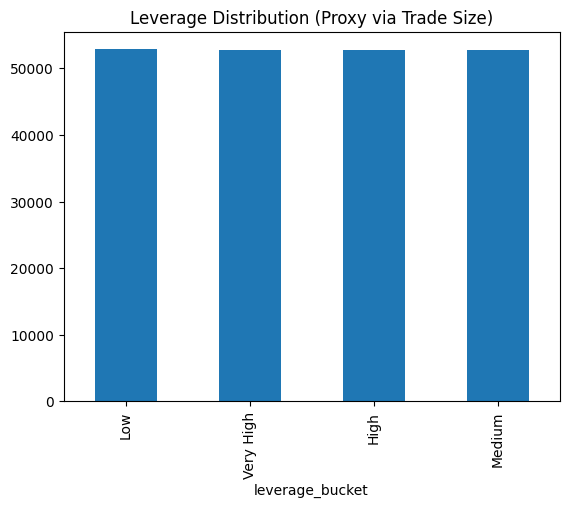

In [26]:
leverage_distribution.plot(kind='bar')
plt.title("Leverage Distribution (Proxy via Trade Size)")
plt.show()

## Leverage Distribution

Since explicit leverage data was not available, trade size (USD) was used as a proxy for leverage.

Trades were grouped into quartiles to represent different levels of risk exposure:
Low, Medium, High, and Very High.

This allows us to analyze how trader risk-taking behavior varies across different market conditions.

In [27]:
perf_by_sentiment = daily_metrics.groupby('classification').agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean'),
    avg_loss=('Closed PnL', lambda x: x[x < 0].mean())
).reset_index()

perf_by_sentiment

,classification,avg_pnl,win_rate,avg_loss
0,Extreme Fear,4619.439053,0.329659,-15534.761937
1,Extreme Greed,5161.922644,0.386387,-6109.737110
2,Fear,5328.818161,0.364033,-6071.371829
3,Greed,3318.100730,0.343559,-16562.519710
4,Neutral,3438.618818,0.355414,-6879.440610


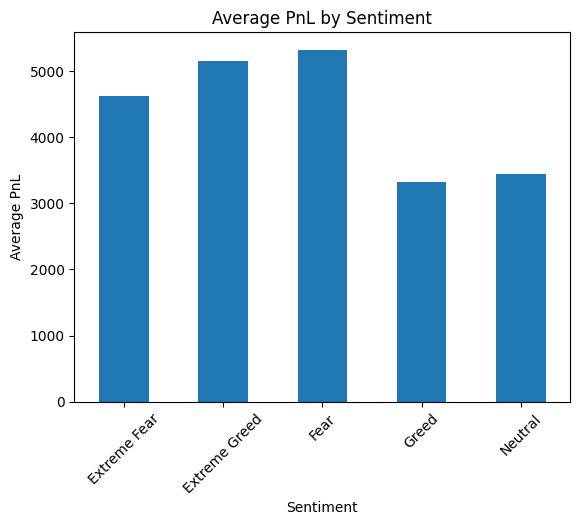

In [28]:
perf_by_sentiment.set_index('classification')['avg_pnl'].plot(kind='bar')
plt.title("Average PnL by Sentiment")
plt.ylabel("Average PnL")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

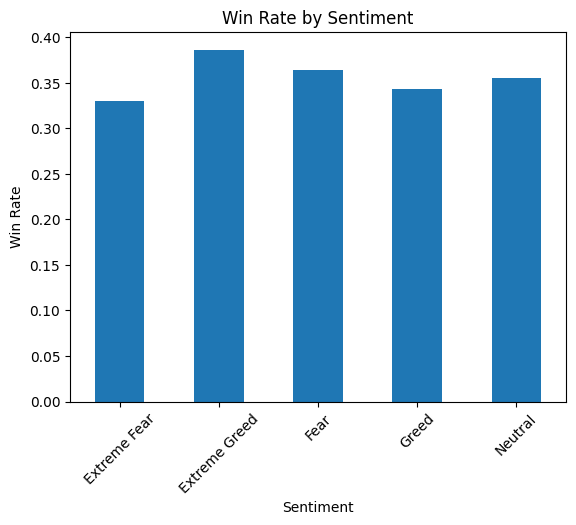

In [29]:
perf_by_sentiment.set_index('classification')['win_rate'].plot(kind='bar')
plt.title("Win Rate by Sentiment")
plt.ylabel("Win Rate")
plt.xlabel("Sentiment")
plt.xticks(rotation=45)
plt.show()

## Performance Analysis: Fear vs Greed

The average PnL varies noticeably across sentiment categories. The highest average PnL is observed during **Fear** and **Extreme Greed** periods, while **Greed** and **Neutral** periods show comparatively lower profitability.

This suggests that traders may perform better during periods of strong market sentiment (both positive and negative), possibly due to clearer market trends.

The win rate, however, remains relatively stable across all sentiment categories, ranging approximately between 33% and 39%. While **Extreme Greed** shows the highest win rate, the differences across categories are not very large.

This indicates that trader accuracy does not change significantly with sentiment. Instead, the variation in profitability is likely driven by factors such as trade size, risk-taking, or market volatility rather than the success rate of trades.

In [30]:
behavior_by_sentiment = daily_metrics.groupby('classification').agg(
    avg_trades=('num_trades', 'mean'),
    avg_size=('Size USD', 'mean'),
    avg_long_ratio=('long_ratio', 'mean')
).reset_index()

behavior_by_sentiment

,classification,avg_trades,avg_size,avg_long_ratio
0,Extreme Fear,133.750000,6773.464125,0.531533
1,Extreme Greed,76.030418,5371.637182,0.473116
2,Fear,98.153968,8975.928546,0.518967
3,Greed,77.628086,6427.866594,0.471594
4,Neutral,100.228723,6963.694861,0.472431


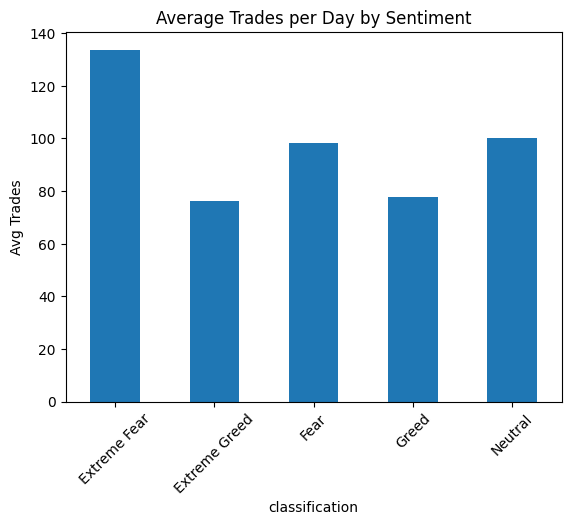

In [31]:
behavior_by_sentiment.set_index('classification')['avg_trades'].plot(kind='bar')
plt.title("Average Trades per Day by Sentiment")
plt.ylabel("Avg Trades")
plt.xticks(rotation=45)
plt.show()

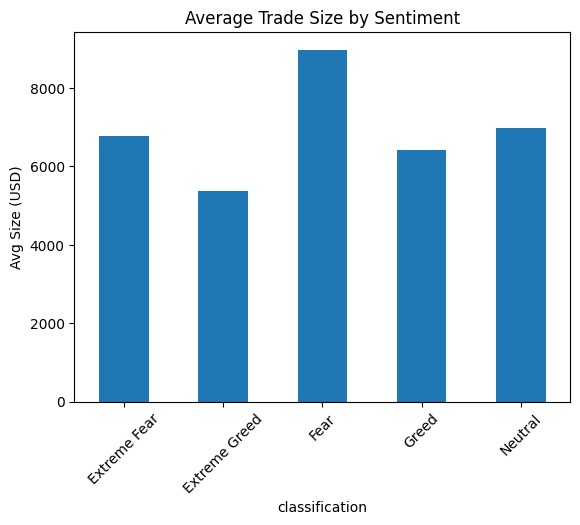

In [32]:
behavior_by_sentiment.set_index('classification')['avg_size'].plot(kind='bar')
plt.title("Average Trade Size by Sentiment")
plt.ylabel("Avg Size (USD)")
plt.xticks(rotation=45)
plt.show()

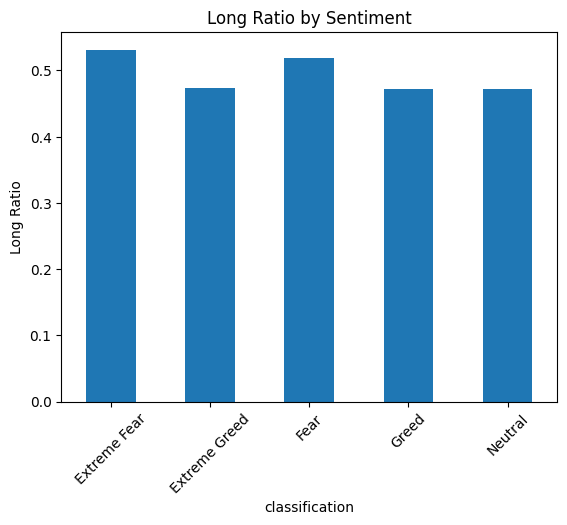

In [33]:
behavior_by_sentiment.set_index('classification')['avg_long_ratio'].plot(kind='bar')
plt.title("Long Ratio by Sentiment")
plt.ylabel("Long Ratio")
plt.xticks(rotation=45)
plt.show()

## Behavior Analysis: Sentiment Impact

Trader behavior varies significantly across different market sentiment conditions.

Trade frequency is highest during Extreme Fear and lowest during Extreme Greed, indicating that traders are more active during periods of strong negative sentiment and less active during extreme positive sentiment.

Average trade size is highest during Fear and relatively lower during Extreme Greed, suggesting that traders take larger positions during uncertain or volatile market conditions and reduce exposure during strong bullish sentiment.

The long ratio is highest during Extreme Fear and Fear, and lower during Greed and Extreme Greed. This indicates that traders tend to take more long positions during negative sentiment periods, possibly anticipating market reversals, while showing more balanced or cautious positioning during positive sentiment.

In [34]:
account_size = daily_metrics.groupby('Account')['Size USD'].mean().reset_index()
median_size = account_size['Size USD'].median()
account_size['leverage_segment'] = account_size['Size USD'].apply(lambda x: 'High' if x >= median_size else 'Low')
account_size.head()

,Account,Size USD,leverage_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,33569.102224,High
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4359.830930,Low
2,0x271b280974205ca63b716753467d5a371de622ab,11057.118419,High
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,484.844294,Low
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2553.757037,Low


In [35]:
seg1 = daily_metrics.merge(account_size[['Account', 'leverage_segment']], on='Account')
seg1.head()

,Account,date,Closed PnL,is_win,Size USD,num_trades,long_ratio,classification,leverage_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0.000000,Extreme Greed,High
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0.000000,Extreme Greed,High
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0.000000,Extreme Greed,High
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,1.000000,Extreme Greed,High
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0.444444,Extreme Greed,High


In [36]:
seg1_perf = seg1.groupby(['leverage_segment', 'classification']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()
seg1_perf

,leverage_segment,classification,avg_pnl,win_rate
0,High,Extreme Fear,7806.192540,0.372041
1,High,Extreme Greed,1245.840519,0.260589
2,High,Fear,9999.606422,0.353284
3,High,Greed,5092.133932,0.281318
4,High,Neutral,4837.142172,0.329413
5,Low,Extreme Fear,2603.329704,0.302846
6,Low,Extreme Greed,7394.673945,0.458111
7,Low,Fear,2568.806916,0.370384
8,Low,Greed,2341.958059,0.377806
9,Low,Neutral,2655.213620,0.369979


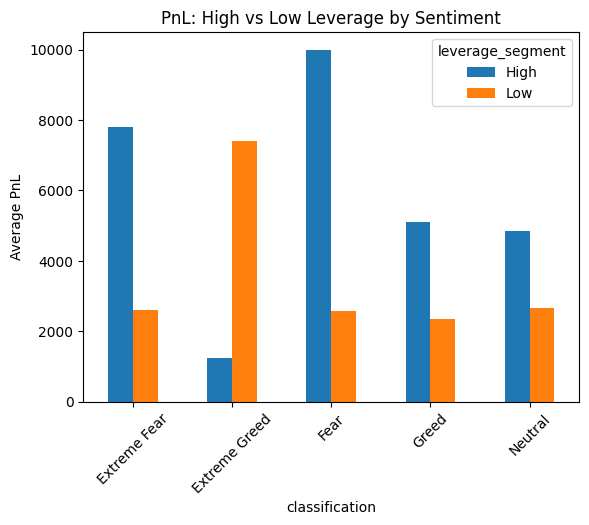

In [37]:
seg1_perf.pivot(index='classification', columns='leverage_segment', values='avg_pnl').plot(kind='bar')
plt.title("PnL: High vs Low Leverage by Sentiment")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

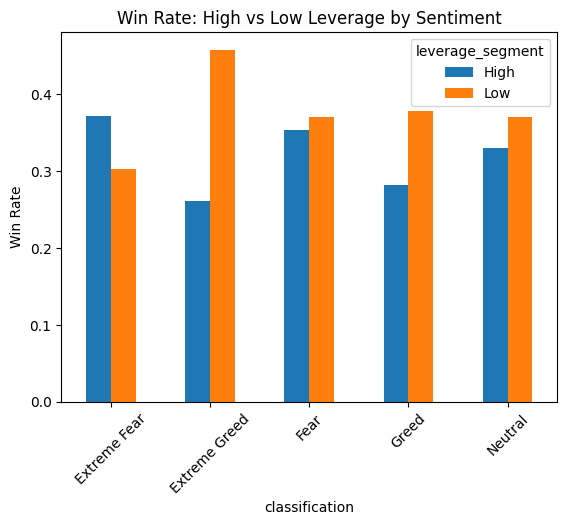

In [38]:
seg1_perf.pivot(index='classification', columns='leverage_segment', values='win_rate').plot(kind='bar')
plt.title("Win Rate: High vs Low Leverage by Sentiment")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

### Segment 1: High vs Low Leverage Traders

High leverage traders (larger position sizes) exhibit significantly higher PnL compared to low leverage traders across most sentiment conditions, particularly during Fear and Extreme Fear periods.

However, this higher profitability comes with lower win rates. Low leverage traders generally achieve higher win rates across all sentiment categories, especially during Extreme Greed, where the gap between the two groups is most pronounced.

This indicates that high leverage traders rely on fewer but larger winning trades, resulting in higher overall PnL but lower consistency. In contrast, low leverage traders follow a more consistent strategy with higher accuracy but lower overall returns.

Additionally, high leverage traders show strong sensitivity to sentiment. Their performance peaks during Fear but drops sharply during Extreme Greed, suggesting that high-risk strategies perform better in volatile or uncertain market conditions but struggle during strong bullish trends.

In [39]:
account_freq = daily_metrics.groupby('Account')['num_trades'].mean().reset_index()
account_freq.head()

,Account,num_trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000
2,0x271b280974205ca63b716753467d5a371de622ab,317.416667
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029


In [40]:
median_freq = account_freq['num_trades'].median()
account_freq['freq_segment'] = account_freq['num_trades'].apply(
    lambda x: 'Frequent' if x >= median_freq else 'Infrequent'
)
account_freq.head()

,Account,num_trades,freq_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,159.083333,Frequent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,140.000000,Frequent
2,0x271b280974205ca63b716753467d5a371de622ab,317.416667,Frequent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,82.166667,Frequent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,46.942029,Infrequent


In [41]:
seg2 = daily_metrics.merge(account_freq[['Account', 'freq_segment']], on='Account')
seg2.head()

,Account,date,Closed PnL,is_win,Size USD,num_trades,long_ratio,classification,freq_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0.000000,Extreme Greed,Frequent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0.000000,Extreme Greed,Frequent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0.000000,Extreme Greed,Frequent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,1.000000,Extreme Greed,Frequent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0.444444,Extreme Greed,Frequent


In [42]:
seg2_perf = seg2.groupby(['freq_segment', 'classification']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()
seg2_perf

,freq_segment,classification,avg_pnl,win_rate
0,Frequent,Extreme Fear,5406.205623,0.359480
1,Frequent,Extreme Greed,4340.279167,0.443665
2,Frequent,Fear,8672.944447,0.411014
3,Frequent,Greed,5494.049560,0.435193
4,Frequent,Neutral,4130.277361,0.422819
5,Infrequent,Extreme Fear,3727.770274,0.295862
6,Infrequent,Extreme Greed,5800.361832,0.341881
7,Infrequent,Fear,2249.775057,0.320775
8,Infrequent,Greed,1942.374895,0.285624
9,Infrequent,Neutral,2891.879207,0.302132


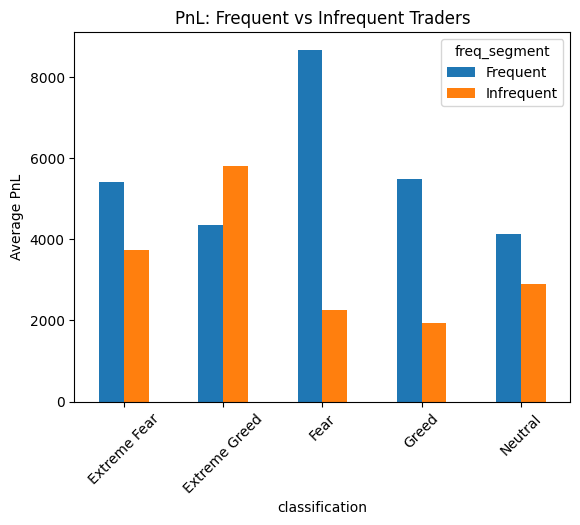

In [43]:
seg2_perf.pivot(index='classification', columns='freq_segment', values='avg_pnl').plot(kind='bar')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

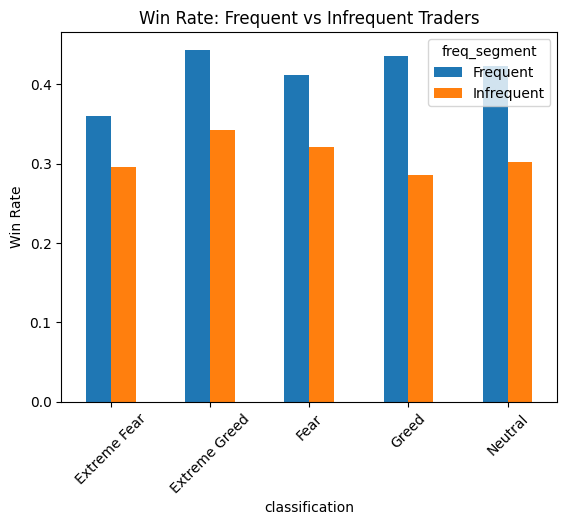

In [44]:
seg2_perf.pivot(index='classification', columns='freq_segment', values='win_rate').plot(kind='bar')
plt.title("Win Rate: Frequent vs Infrequent Traders")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

### Segment 2: Frequent vs Infrequent Traders

Frequent traders consistently achieve higher PnL compared to infrequent traders across most sentiment conditions, particularly during Fear and Greed periods.

However, during Extreme Greed, infrequent traders outperform frequent traders in terms of PnL, suggesting that less active traders may benefit more during strong bullish conditions.

Frequent traders also exhibit higher win rates across all sentiment categories, indicating that they are generally more accurate and consistent in their trading decisions.

Additionally, frequent traders show stronger sensitivity to sentiment changes, with their PnL peaking during Fear and dropping during Neutral conditions. In contrast, infrequent traders display more stable but lower performance across sentiment regimes.

Overall, this suggests that frequent trading is associated with both higher profitability and higher consistency, but may also involve greater exposure to market condition changes.

In [45]:
account_win = daily_metrics.groupby('Account')['is_win'].mean().reset_index()
account_win.head()

,Account,is_win
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.352333
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.397134
2,0x271b280974205ca63b716753467d5a371de622ab,0.379952
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.452509
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.498708


In [46]:
median_win = account_win['is_win'].median()
account_win['consistency_segment'] = account_win['is_win'].apply(
    lambda x: 'Consistent' if x >= median_win else 'Inconsistent'
)
account_win.head()

,Account,is_win,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,0.352333,Consistent
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,0.397134,Consistent
2,0x271b280974205ca63b716753467d5a371de622ab,0.379952,Consistent
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,0.452509,Consistent
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,0.498708,Consistent


In [47]:
seg3 = daily_metrics.merge(account_win[['Account', 'consistency_segment']], on='Account')
seg3.head()

,Account,date,Closed PnL,is_win,Size USD,num_trades,long_ratio,classification,consistency_segment
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-11,0.0,0.000000,5089.718249,177,0.000000,Extreme Greed,Consistent
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-17,0.0,0.000000,7976.664412,68,0.000000,Extreme Greed,Consistent
2,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-18,0.0,0.000000,23734.500000,40,0.000000,Extreme Greed,Consistent
3,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-22,-21227.0,0.000000,28186.666667,12,1.000000,Extreme Greed,Consistent
4,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-11-26,1603.1,0.444444,17248.148148,27,0.444444,Extreme Greed,Consistent


In [48]:
seg3_perf = seg3.groupby(['consistency_segment', 'classification']).agg(
    avg_pnl=('Closed PnL', 'mean'),
    win_rate=('is_win', 'mean')
).reset_index()
seg3_perf

,consistency_segment,classification,avg_pnl,win_rate
0,Consistent,Extreme Fear,6048.245870,0.384186
1,Consistent,Extreme Greed,4188.145197,0.488396
2,Consistent,Fear,8298.034543,0.444342
3,Consistent,Greed,3439.070638,0.471071
4,Consistent,Neutral,2708.983741,0.468152
5,Inconsistent,Extreme Fear,3117.360091,0.272336
6,Inconsistent,Extreme Greed,6092.260205,0.288930
7,Inconsistent,Fear,2828.425419,0.296404
8,Inconsistent,Greed,3249.267973,0.271003
9,Inconsistent,Neutral,3955.996418,0.275473


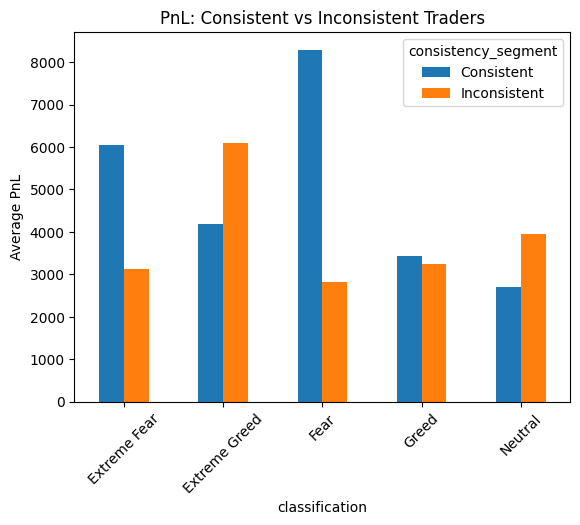

In [49]:
seg3_perf.pivot(index='classification', columns='consistency_segment', values='avg_pnl').plot(kind='bar')
plt.title("PnL: Consistent vs Inconsistent Traders")
plt.ylabel("Average PnL")
plt.xticks(rotation=45)
plt.show()

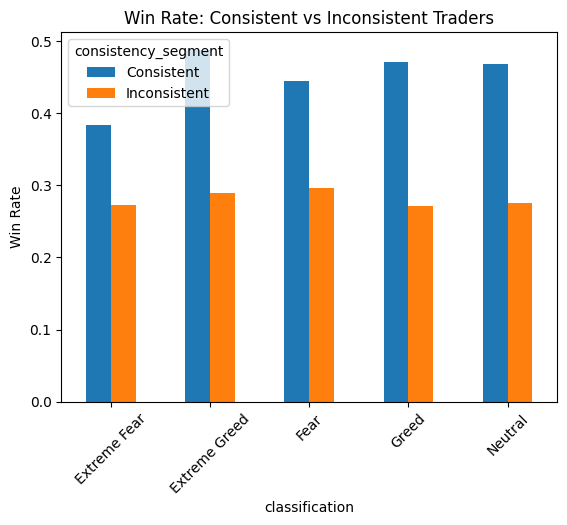

In [50]:
seg3_perf.pivot(index='classification', columns='consistency_segment', values='win_rate').plot(kind='bar')
plt.title("Win Rate: Consistent vs Inconsistent Traders")
plt.ylabel("Win Rate")
plt.xticks(rotation=45)
plt.show()

### Segment 3: Consistent vs Inconsistent Traders

Consistent traders (higher win rates) achieve significantly higher win rates than inconsistent traders across all sentiment conditions, indicating more reliable and disciplined trading behavior.

In terms of profitability, consistent traders outperform inconsistent traders during Fear and Extreme Fear periods, where they achieve substantially higher PnL.

However, during Extreme Greed and Neutral conditions, inconsistent traders outperform consistent traders in terms of PnL, suggesting that less consistent strategies may benefit more during strong bullish or stable market conditions.

This indicates that consistent traders perform better in uncertain or volatile environments, while inconsistent traders may capture higher gains during strong upward trends.

Overall, consistency improves trading accuracy and stability, but does not always guarantee the highest profitability under all market conditions.

## Strategy Recommendations

### 1. Sentiment-Adaptive Risk Strategy

Adjust position sizing and aggressiveness based on market sentiment:

- During Fear and Extreme Fear:
  - Increase position sizes moderately
  - Favor consistent, disciplined trading strategies
  - Take advantage of higher profitability observed in volatile conditions

- During Extreme Greed:
  - Reduce position sizes and avoid high leverage
  - Limit trade frequency to avoid overtrading
  - Focus on selective, high-conviction trades

This approach leverages the observation that high-risk and consistent strategies perform best in volatile markets, while aggressive behavior under strong bullish sentiment leads to lower performance.

---

### 2. Consistency-Driven Trading Strategy with Conditional Activity

Prioritize high win-rate (consistent) strategies while dynamically adjusting trading activity:

- Maintain disciplined, high-accuracy trading as a base strategy across all conditions
- Increase trading frequency during Fear and Greed, where frequent traders show both higher PnL and win rates
- Reduce trading frequency during Extreme Greed, where infrequent traders outperform

This strategy combines the stability of consistent traders with the profitability of frequent trading, while avoiding overtrading during market conditions where it is detrimental.

In [51]:
df = daily_metrics.copy()
df = df.sort_values(['Account', 'date'])
# next-day pnl
df['next_day_pnl'] = df.groupby('Account')['Closed PnL'].shift(-1)
df = df.dropna(subset=['next_day_pnl'])

In [52]:
def pnl_bucket(x):
    if x > 0:
        return 'Profit'
    elif x < 0:
        return 'Loss'
    else:
        return 'Neutral'
df['target'] = df['next_day_pnl'].apply(pnl_bucket)

In [53]:
from sklearn.preprocessing import LabelEncoder

In [54]:
le = LabelEncoder()
df['sentiment_encoded'] = le.fit_transform(df['classification'])

In [55]:
features = ['num_trades', 'Size USD', 'long_ratio', 'sentiment_encoded']
X = df[features]
y = df['target']

In [56]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report

In [57]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [58]:
model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [59]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

        Loss       0.08      0.03      0.04        38
     Neutral       0.48      0.35      0.41       136
      Profit       0.67      0.82      0.74       288

    accuracy                           0.62       462
   macro avg       0.41      0.40      0.40       462
weighted avg       0.57      0.62      0.58       462



<Axes: >

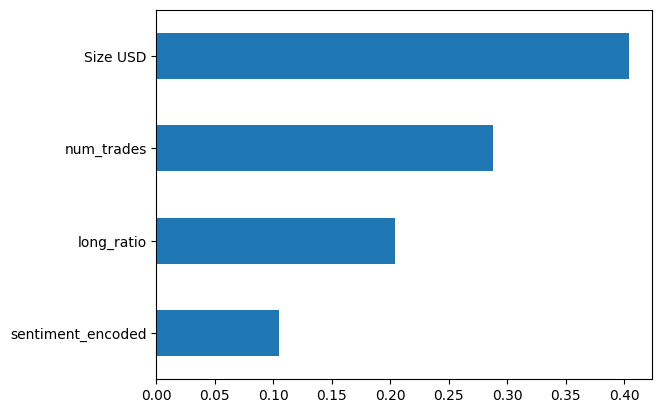

In [60]:
importance = pd.Series(model.feature_importances_, index=features)
importance.sort_values().plot(kind='barh')

## Bonus: Predictive Modeling

A simple classification model was developed to predict next-day trader profitability (Profit / Loss / Neutral) using behavioral and sentiment-based features.

The model achieves an accuracy of approximately 62%, with strong performance in predicting profitable outcomes, while struggling with less frequent loss cases due to class imbalance.

Feature importance analysis shows that trade size (Size USD) is the most influential factor in predicting next-day profitability, followed by trading activity (number of trades).

The long ratio also contributes moderately, indicating that directional bias has some predictive value.

Market sentiment has the lowest relative importance among the features, suggesting that trader behavior plays a more significant role than sentiment alone in determining profitability.

Overall, the results indicate that while sentiment provides useful context, trading behavior—particularly position sizing and activity level—has stronger predictive power for trader performance.

In [61]:
cluster_df = daily_metrics.groupby('Account').agg({
    'Closed PnL': 'mean',
    'is_win': 'mean',
    'num_trades': 'mean',
    'Size USD': 'mean'
}).reset_index()
cluster_df.head()

,Account,Closed PnL,is_win,num_trades,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,0.352333,159.083333,33569.102224
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,0.397134,140.000000,4359.830930
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,0.379952,317.416667,11057.118419
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,0.452509,82.166667,484.844294
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,0.498708,46.942029,2553.757037


In [62]:
from sklearn.preprocessing import StandardScaler

In [63]:
features = ['Closed PnL', 'is_win', 'num_trades', 'Size USD']
scaler = StandardScaler()
X_scaled = scaler.fit_transform(cluster_df[features])

In [64]:
from sklearn.cluster import KMeans

In [65]:
inertia = []
for k in range(2, 7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

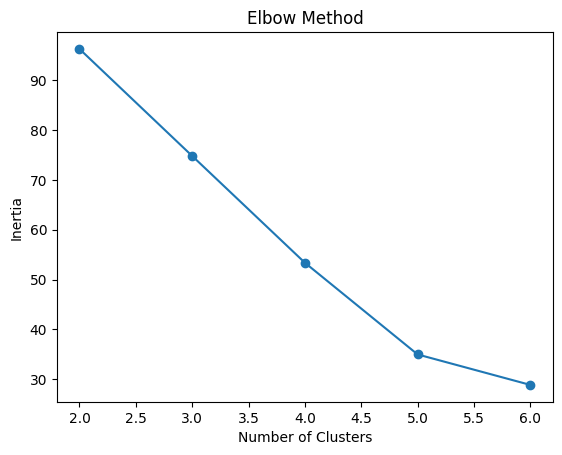

In [66]:
plt.plot(range(2, 7), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.show()

In [83]:
kmeans = KMeans(n_clusters=5, random_state=42)
cluster_df['cluster'] = kmeans.fit_predict(X_scaled)
cluster_df.head()

,Account,Closed PnL,is_win,num_trades,Size USD,cluster
0,0x083384f897ee0f19899168e3b1bec365f52a9012,66676.242499,0.352333,159.083333,33569.102224,2
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,920.871548,0.397134,140.000000,4359.830930,4
2,0x271b280974205ca63b716753467d5a371de622ab,-5869.682610,0.379952,317.416667,11057.118419,4
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,817.684040,0.452509,82.166667,484.844294,4
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,2444.318913,0.498708,46.942029,2553.757037,4


In [84]:
cluster_summary = cluster_df.groupby('cluster')[features].mean()
cluster_summary

,Closed PnL,is_win,num_trades,Size USD
cluster,,,,
0,6040.313825,0.360858,109.237253,22170.241328
1,5317.879385,0.255814,69.919193,4606.091437
2,66676.242499,0.352333,159.083333,33569.102224
3,33577.278794,0.455625,756.857143,4528.364243
4,2039.770230,0.449821,102.039309,4636.515016


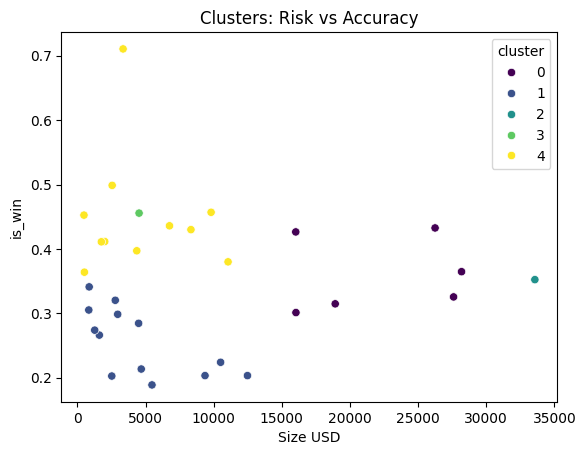

In [85]:
sns.scatterplot(
    data=cluster_df,
    x='Size USD',
    y='is_win',
    hue='cluster',
    palette='viridis'
)
plt.title("Clusters: Risk vs Accuracy")
plt.show()

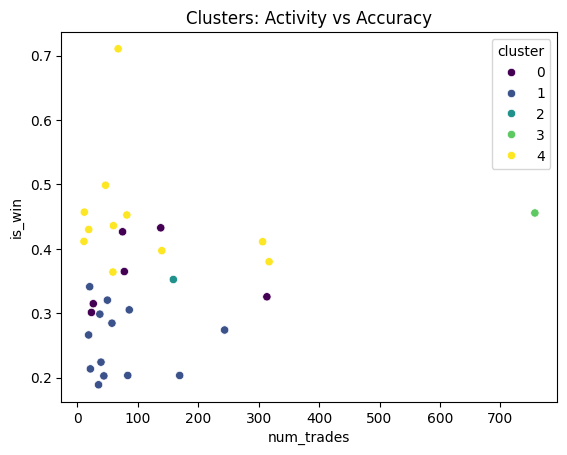

In [86]:
sns.scatterplot(
    data=cluster_df,
    x='num_trades',
    y='is_win',
    hue='cluster',
    palette='viridis'
)
plt.title("Clusters: Activity vs Accuracy")
plt.show()

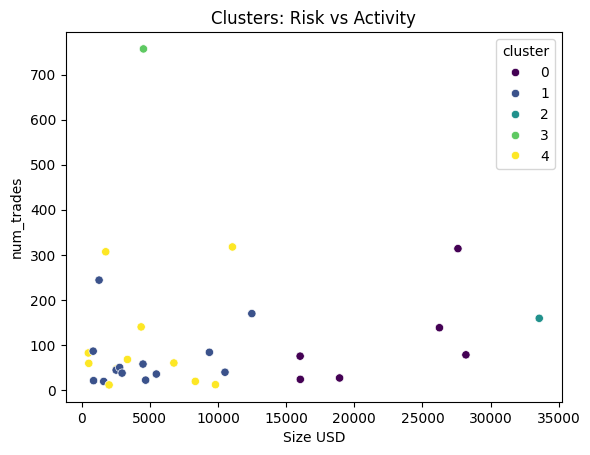

In [87]:
sns.scatterplot(
    data=cluster_df,
    x='Size USD',
    y='num_trades',
    hue='cluster',
    palette='viridis'
)
plt.title("Clusters: Risk vs Activity")
plt.show()

## Bonus: Trader Clustering

Traders were grouped into behavioral archetypes using K-Means clustering based on key features: average PnL, win rate, trading frequency, and trade size.

Five distinct clusters were identified, each representing a different trading style:

### Cluster 0: High-Risk, High-Activity Traders  
These traders exhibit high trade sizes and high trading frequency, with strong profitability and moderate win rates. They represent aggressive traders who take larger positions and trade frequently to generate returns.

### Cluster 1: Moderate Traders with Lower Accuracy  
This group shows moderate profitability and lower win rates, with relatively lower trade sizes and activity. These traders appear less consistent and may struggle with decision accuracy.

### Cluster 2: Aggressive High-Volume Traders  
These traders have the highest trading activity and largest position sizes, along with strong profitability. They represent highly aggressive traders who rely on volume and risk-taking to achieve high returns.

### Cluster 3: Highly Active and Consistent Traders  
This cluster shows the highest trading frequency and the highest win rates, indicating disciplined and highly engaged traders who combine activity with strong accuracy.

### Cluster 4: Conservative but Accurate Traders  
These traders exhibit lower profitability but relatively high win rates, with moderate activity and smaller trade sizes. This suggests a cautious strategy focused on consistency rather than maximizing returns.

### Key Insights

The clustering reveals that trader behavior is highly diverse, with clear differences in risk-taking, activity levels, and consistency.

- High profitability is often associated with higher trade sizes and activity levels.
- High win rates do not always translate to the highest PnL, indicating a trade-off between accuracy and aggressiveness.
- Different trading styles perform differently under varying market conditions, reinforcing the importance of adapting strategies based on behavior and sentiment.